# Seasonal Concept Drift Detection — BMSB Sticky Trap Images

**Species:** *Halyomorpha halys* (Brown Marmorated Stink Bug, BMSB)
**Method:** Deep Convolutional Autoencoder (PyTorch) trained on **Q3** (summer) images.
**Goal:** Detect concept drift by comparing reconstruction errors between Q3 and Q4.

#### Dataset
- 476 images (1920×1080) from IoT sticky-trap camera, Jun–Nov 2024
- Polygon annotations + binary masks for each HH instance
- 9 sequential trap replacements over the season

#### Seasonal Splits
| Quarter | Months | Description |
|---------|--------|-------------|
| Q3 | Jul–Sep 2024 | Summer / peak growing season (reference) |
| Q4 | Oct–Nov 2024 | Autumn / late season (drift target) |

> **Note:** Q2 (June) was excluded due to insufficient sample size.

#### Pipeline Overview
1. Import libraries & set configuration
2. Discover and explore the dataset
3. Assign seasonal quarters & filter to Q3/Q4
4. Load & preprocess images
5. Build a Deep Convolutional Autoencoder
6. Train on Q3 (summer) with early stopping
7. Compute reconstruction errors per quarter and detect drift
8. Visualize results

## 1. Import Required Libraries

In [1]:
import os
import re
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
print(f"  PyTorch version: {torch.__version__}")

Using device: cpu
  PyTorch version: 2.10.0+cpu


## 2. Configuration and Constants

In [2]:
CONFIG = {
    # ── Paths ──
    "dataset_root": r"..\data\raw\DatasetV3",
    "images_dir":   r"..\data\raw\DatasetV3\Images",
    "csv_path":     r"..\data\raw\DatasetV3\Num_HHs.csv",
    "output_dir":   r"..\results",

    # ── Image dimensions (resize target) ──
    # Original: 1920×1080. Resize to 128×72 (same 16:9 aspect ratio)
    "img_height": 72,
    "img_width": 128,
    "img_channels": 3,

    # ── Autoencoder hyper-parameters ──
    "latent_dim": 128,
    "learning_rate": 1e-3,
    "batch_size": 16,
    "epochs": 100,
    "early_stop_patience": 10,

    # ── Data-split ratios (Q3 reference set) ──
    "val_ratio": 0.15,
    "test_ratio": 0.15,

    # ── Reproducibility ──
    "seed": 42,
}

np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

os.makedirs(CONFIG["output_dir"], exist_ok=True)
print("Configuration loaded ✓")
print(f"  Image target size : {CONFIG['img_width']}×{CONFIG['img_height']}×{CONFIG['img_channels']}")
print(f"  Latent dimension  : {CONFIG['latent_dim']}")
print(f"  Epochs / patience : {CONFIG['epochs']} / {CONFIG['early_stop_patience']}")
print(f"  Q3 splits         : Train {1-CONFIG['val_ratio']-CONFIG['test_ratio']:.0%} | Val {CONFIG['val_ratio']:.0%} | Test {CONFIG['test_ratio']:.0%}")

Configuration loaded ✓
  Image target size : 128×72×3
  Latent dimension  : 128
  Epochs / patience : 100 / 10
  Q3 splits         : Train 70% | Val 15% | Test 15%


## 3. Data Discovery and Exploration

Load the CSV metadata and image directory, parse timestamps, and build a master catalogue.

In [3]:
def discover_dataset(images_dir: str, csv_path: str) -> pd.DataFrame:
    """
    Build a catalogue DataFrame from the BMSB dataset.

    Parses image filenames (YYYY-MM-DD_HH-MM-SS.jpg), joins with
    Num_HHs.csv for HH counts and trap IDs.

    Returns:
        DataFrame with columns: filename, datetime, date, hour,
        num_hh, trap, filepath
    """
    csv_df = pd.read_csv(csv_path)
    csv_df.rename(columns={"Filename": "filename", "Num_HHs": "num_hh", "Trap": "trap"}, inplace=True)

    date_pattern = re.compile(r"(\d{4})-(\d{2})-(\d{2})_(\d{2})-(\d{2})-(\d{2})\.jpg")

    records = []
    for fname in sorted(os.listdir(images_dir)):
        m = date_pattern.match(fname)
        if m:
            y, mo, d, h, mi, s = m.groups()
            dt = datetime(int(y), int(mo), int(d), int(h), int(mi), int(s))
            records.append({
                "filename": fname,
                "datetime": dt,
                "date": dt.date(),
                "hour": int(h),
                "filepath": os.path.join(images_dir, fname),
            })

    df = pd.DataFrame(records)
    df = df.merge(csv_df, on="filename", how="left")
    df.sort_values("datetime", inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


catalogue = discover_dataset(CONFIG["images_dir"], CONFIG["csv_path"])

print(f"Total images discovered: {len(catalogue)}")
print(f"Date range: {catalogue['date'].min()} → {catalogue['date'].max()}")
print(f"Traps: {sorted(catalogue['trap'].unique())}")
print(f"HH count range: {catalogue['num_hh'].min()} – {catalogue['num_hh'].max()}")
print()
print(catalogue.head(10))

Total images discovered: 476
Date range: 2024-06-29 → 2024-11-10
Traps: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
HH count range: 0 – 29

                  filename            datetime        date  hour  \
0  2024-06-29_00-05-03.jpg 2024-06-29 00:05:03  2024-06-29     0   
1  2024-06-29_03-05-03.jpg 2024-06-29 03:05:03  2024-06-29     3   
2  2024-06-29_06-05-03.jpg 2024-06-29 06:05:03  2024-06-29     6   
3  2024-06-29_18-05-03.jpg 2024-06-29 18:05:03  2024-06-29    18   
4  2024-06-30_00-05-03.jpg 2024-06-30 00:05:03  2024-06-30     0   
5  2024-06-30_03-05-03.jpg 2024-06-30 03:05:03  2024-06-30     3   
6  2024-06-30_06-05-03.jpg 2024-06-30 06:05:03  2024-06-30     6   
7  2024-07-01_00-05-05.jpg 2024-07-01 00:05:05  2024-07-01     0   
8  2024-07-01_03-05-03.jpg 2024-07-01 03:05:03  2024-07-01     3   
9  2024-07-01_06-05-03.jpg 2024-07-01 06:05:03  2024-07-01     6   

                                     

## 4. Assign Seasonal Quarters and Filter to Q3 / Q4

Split images by calendar quarter and keep only the two quarters with sufficient data:
- **Q3** (Jul–Sep): summer peak — **reference period** for training
- **Q4** (Oct–Dec): autumn late season — **drift target**


In [4]:
def assign_quarter(dt):
    """Map a date to its calendar quarter label."""
    month = dt.month if hasattr(dt, 'month') else dt.date().month
    if month <= 3:
        return "Q1"
    elif month <= 6:
        return "Q2"
    elif month <= 9:
        return "Q3"
    else:
        return "Q4"


catalogue["quarter"] = catalogue["datetime"].apply(assign_quarter)
catalogue["month"] = catalogue["datetime"].apply(lambda x: x.month)
catalogue["month_name"] = catalogue["datetime"].apply(lambda x: x.strftime("%b"))

print("Images per quarter (before filtering):")
print(catalogue["quarter"].value_counts().sort_index())
print()

# ── Keep only Q3 and Q4 (Q2 has too few samples) ──
catalogue = catalogue[catalogue["quarter"].isin(["Q3", "Q4"])].reset_index(drop=True)
print(f"Filtered to Q3 and Q4: {len(catalogue)} images")
print()

print("Images per quarter:")
print(catalogue["quarter"].value_counts().sort_index())
print()

print("Images per month:")
print(catalogue.groupby(["quarter", "month_name"]).size().reset_index(name="count").to_string(index=False))
print()

print("Mean HH count per quarter:")
print(catalogue.groupby("quarter")["num_hh"].agg(["count", "mean", "std", "min", "max"]).round(2))

Images per quarter (before filtering):
quarter
Q2      7
Q3    266
Q4    203
Name: count, dtype: int64

Filtered to Q3 and Q4: 469 images

Images per quarter:
quarter
Q3    266
Q4    203
Name: count, dtype: int64

Images per month:
quarter month_name  count
     Q3        Aug     84
     Q3        Jul     34
     Q3        Sep    148
     Q4        Nov     50
     Q4        Oct    153

Mean HH count per quarter:
         count  mean   std  min  max
quarter                             
Q3         266  9.53  5.88    0   29
Q4         203  6.06  3.10    0   15


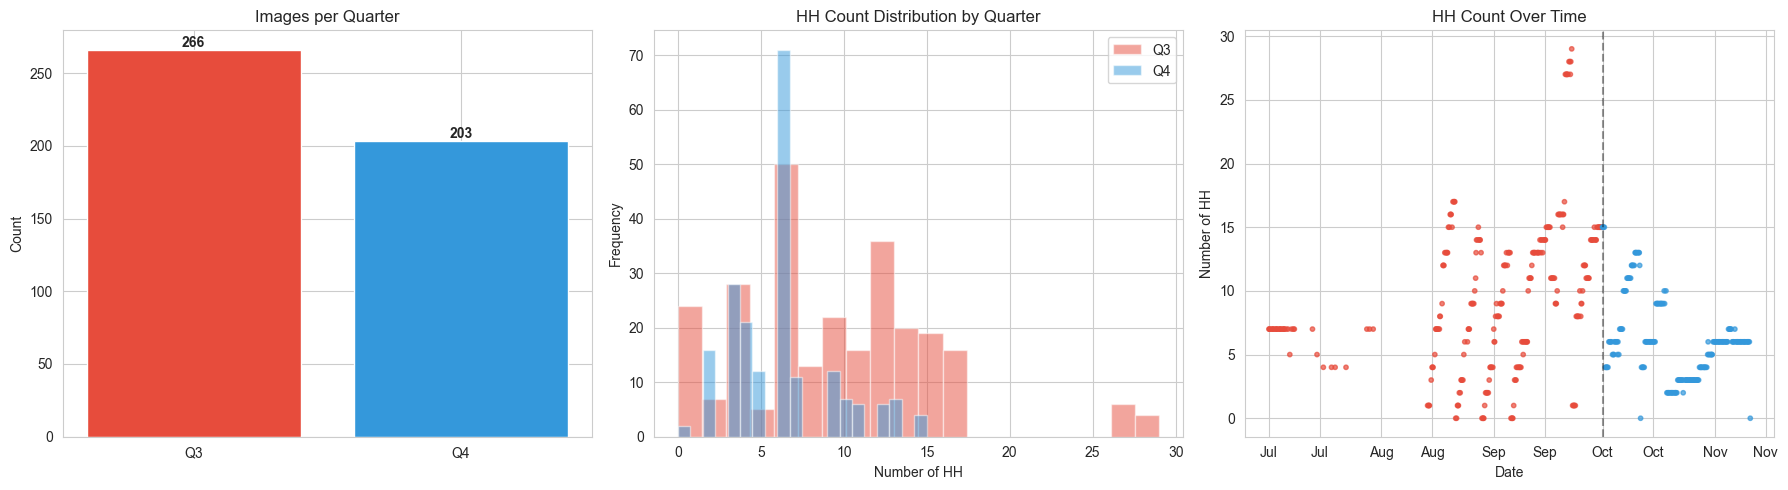

In [5]:
# ── Visualize quarter distributions ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Images per quarter bar chart
quarter_counts = catalogue["quarter"].value_counts().sort_index()
colors = {"Q3": "#e74c3c", "Q4": "#3498db"}
axes[0].bar(quarter_counts.index, quarter_counts.values,
            color=[colors.get(q, "grey") for q in quarter_counts.index])
axes[0].set_title("Images per Quarter")
axes[0].set_ylabel("Count")
for i, (q, v) in enumerate(quarter_counts.items()):
    axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

# 2. HH count distribution by quarter
for q in sorted(catalogue["quarter"].unique()):
    subset = catalogue[catalogue["quarter"] == q]
    axes[1].hist(subset["num_hh"], bins=20, alpha=0.5, label=q, color=colors.get(q, "grey"))
axes[1].set_title("HH Count Distribution by Quarter")
axes[1].set_xlabel("Number of HH")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# 3. Timeline of HH counts
axes[2].scatter(catalogue["datetime"], catalogue["num_hh"],
                c=[colors.get(q, "grey") for q in catalogue["quarter"]],
                s=10, alpha=0.7)
axes[2].set_title("HH Count Over Time")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Number of HH")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
# Quarter boundary
axes[2].axvline(datetime(2024, 10, 1), color="black", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 5. Data Loading and Preprocessing

In [6]:
def load_images_from_paths(
    file_paths: list,
    target_height: int = CONFIG["img_height"],
    target_width: int = CONFIG["img_width"],
) -> np.ndarray:
    """
    Load RGB images, resize, and normalise to [0, 1].

    Returns:
        np.ndarray of shape (N, C, H, W) with float32 values in [0, 1].
    """
    images = []
    skipped = 0
    for fp in file_paths:
        try:
            img = Image.open(fp).convert("RGB")
            img = img.resize((target_width, target_height), Image.BILINEAR)
            arr = np.asarray(img, dtype=np.float32) / 255.0
            arr = arr.transpose(2, 0, 1)  # (H, W, C) → (C, H, W)
            images.append(arr)
        except Exception as e:
            skipped += 1
            print(f"  [WARN] Skipping {fp}: {e}")
    if skipped:
        print(f"  Skipped {skipped}/{len(file_paths)} images.")
    return np.stack(images, axis=0)


# Quick sanity check
_sample = load_images_from_paths(catalogue.iloc[:3]["filepath"].tolist())
print(f"Sample batch shape: {_sample.shape}  dtype: {_sample.dtype}  range: [{_sample.min():.3f}, {_sample.max():.3f}]")
del _sample

Sample batch shape: (3, 3, 72, 128)  dtype: float32  range: [0.008, 1.000]


## 6. Split Data by Quarter

- **Q3** (reference): 70% train / 15% validation / 15% test
- **Q4** (drift target): 100% used as test set

In [7]:
def split_by_quarter(
    df: pd.DataFrame,
    reference_quarter: str = "Q3",
    val_ratio: float = CONFIG["val_ratio"],
    test_ratio: float = CONFIG["test_ratio"],
    seed: int = CONFIG["seed"],
):
    """
    Split data using one quarter as reference (train/val/test)
    and all other quarters as drift test sets.

    Returns:
        dict with X_train, X_val, X_test_ref, and X_test_{quarter}
        for each non-reference quarter.
    """
    ref_df = df[df["quarter"] == reference_quarter].reset_index(drop=True)
    other_quarters = sorted([q for q in df["quarter"].unique() if q != reference_quarter])

    # Split reference quarter into train / val / test
    val_test_ratio = val_ratio + test_ratio
    paths_ref = ref_df["filepath"].tolist()
    dates_ref = ref_df["datetime"].tolist()

    train_paths, valtest_paths, train_dates, valtest_dates = train_test_split(
        paths_ref, dates_ref, test_size=val_test_ratio, random_state=seed, shuffle=True
    )
    relative_test = test_ratio / val_test_ratio
    val_paths, test_paths, val_dates, test_dates = train_test_split(
        valtest_paths, valtest_dates, test_size=relative_test, random_state=seed, shuffle=True
    )

    print(f"Loading {reference_quarter} train images ({len(train_paths)})...")
    X_train = load_images_from_paths(train_paths)
    print(f"Loading {reference_quarter} val images ({len(val_paths)})...")
    X_val = load_images_from_paths(val_paths)
    print(f"Loading {reference_quarter} test images ({len(test_paths)})...")
    X_test_ref = load_images_from_paths(test_paths)

    result = {
        "reference_quarter": reference_quarter,
        "X_train": X_train,
        "X_val": X_val,
        "X_test_ref": X_test_ref,
        "dates_train": sorted(train_dates),
        "dates_val": sorted(val_dates),
        "dates_test_ref": sorted(test_dates),
        "n_train": len(X_train),
        "n_val": len(X_val),
        "n_test_ref": len(X_test_ref),
    }

    for q in other_quarters:
        q_df = df[df["quarter"] == q].reset_index(drop=True)
        print(f"Loading {q} test images ({len(q_df)})...")
        X_q = load_images_from_paths(q_df["filepath"].tolist())
        result[f"X_test_{q}"] = X_q
        result[f"dates_test_{q}"] = sorted(q_df["datetime"].tolist())
        result[f"n_test_{q}"] = len(X_q)

    print()
    print(f"  {reference_quarter} (reference): Train={result['n_train']} | Val={result['n_val']} | Test={result['n_test_ref']}")
    for q in other_quarters:
        print(f"  {q} (drift target): Test={result[f'n_test_{q}']}")

    return result, other_quarters


data_splits, drift_quarters = split_by_quarter(catalogue, reference_quarter="Q3")
print("\nData splitting complete ✓")

Loading Q3 train images (186)...
Loading Q3 val images (40)...
Loading Q3 test images (40)...
Loading Q4 test images (203)...

  Q3 (reference): Train=186 | Val=40 | Test=40
  Q4 (drift target): Test=203

Data splitting complete ✓


## 7. Deep Convolutional Autoencoder Architecture

**Encoder:** Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Conv2D(128) → MaxPool → Flatten → Dense(latent_dim)  
**Decoder:** Dense → Reshape → ConvTranspose2D(128) → ConvTranspose2D(64) → ConvTranspose2D(32) → Conv2D(3, sigmoid)

Input: `(N, 3, 72, 128)` → Bottleneck: `(N, 128)` → Output: `(N, 3, 72, 128)`

In [8]:
class ConvAutoencoder(nn.Module):
    """
    Deep Convolutional Autoencoder for RGB image reconstruction.

    Input shape : (N, 3, 72, 128)
    After encoder convolutions: (N, 128, 9, 16)
    Latent vector: (N, latent_dim)
    Output shape: (N, 3, 72, 128)
    """

    def __init__(self, latent_dim: int = 128):
        super().__init__()
        self.latent_dim = latent_dim

        # ── Encoder ──
        self.encoder_conv = nn.Sequential(
            # Block 1: (3, 72, 128) → (32, 36, 64)
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: (32, 36, 64) → (64, 18, 32)
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: (64, 18, 32) → (128, 9, 16)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Spatial dimensions after conv encoder: 9 × 16 with 128 channels
        self._flat_size = 128 * 9 * 16  # = 18,432

        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._flat_size, latent_dim),
            nn.ReLU(inplace=True),
        )

        # ── Decoder ──
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, self._flat_size),
            nn.ReLU(inplace=True),
        )

        self.decoder_conv = nn.Sequential(
            # (128, 9, 16) → (64, 18, 32)
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # (64, 18, 32) → (32, 36, 64)
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # (32, 36, 64) → (32, 72, 128)
            nn.ConvTranspose2d(32, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # Final 1×1 conv to 3 channels with Sigmoid
            nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        h = self.encoder_conv(x)
        z = self.encoder_fc(h)
        return z

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        h = self.decoder_fc(z)
        h = h.view(-1, 128, 9, 16)
        x_recon = self.decoder_conv(h)
        return x_recon

    def forward(self, x: torch.Tensor):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z


# ── Verify architecture ──
_test_model = ConvAutoencoder(latent_dim=CONFIG["latent_dim"]).to(device)
_dummy = torch.randn(2, 3, CONFIG["img_height"], CONFIG["img_width"]).to(device)
_out, _z = _test_model(_dummy)
print(f"Input  shape : {_dummy.shape}")
print(f"Latent shape : {_z.shape}")
print(f"Output shape : {_out.shape}")
print(f"Total params : {sum(p.numel() for p in _test_model.parameters()):,}")
del _test_model, _dummy, _out, _z

Input  shape : torch.Size([2, 3, 72, 128])
Latent shape : torch.Size([2, 128])
Output shape : torch.Size([2, 3, 72, 128])
Total params : 4,933,475


## 8. Training Utilities with Early Stopping

In [9]:
def train_autoencoder(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float,
    patience: int,
    device: torch.device,
) -> dict:
    """
    Train the autoencoder with MSE loss and Adam optimiser.
    Implements early stopping based on validation loss.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "best_epoch": 0}

    for epoch in range(1, epochs + 1):
        # ── Training ──
        model.train()
        running_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            recon, _ = model(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ── Validation ──
        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(device)
                recon, _ = model(batch)
                val_running += criterion(recon, batch).item() * batch.size(0)
        val_loss = val_running / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # ── Early stopping ──
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            history["best_epoch"] = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 10 == 0 or epoch == 1 or epochs_no_improve == patience:
            marker = "  ★ best" if epochs_no_improve == 0 else ""
            print(f"    Epoch {epoch:>3d}/{epochs}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}{marker}")

        if epochs_no_improve >= patience:
            print(f"    ⇢ Early stopping at epoch {epoch}. Best epoch: {history['best_epoch']}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


def plot_loss_curves(history: dict, title: str = "Training Curves"):
    """Plot training and validation loss curves."""
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(history["train_loss"], label="Train Loss")
    ax.plot(history["val_loss"], label="Val Loss")
    ax.axvline(history["best_epoch"] - 1, color="grey", ls="--", alpha=0.6,
               label=f"Best epoch ({history['best_epoch']})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


print("Training utilities defined ✓")

Training utilities defined ✓


## 9. Train Autoencoder on Q3 (Summer Reference)

Train one ConvAutoencoder on Q3 images. The model learns what "normal" summer sticky-trap images look like. Later quarters should show higher reconstruction error if distribution shifts.

  TRAINING: ConvAutoencoder on Q3 (Summer)
    Epoch   1/100  train_loss=0.099472  val_loss=0.096792  ★ best
    Epoch  10/100  train_loss=0.015210  val_loss=0.014332  ★ best
    Epoch  20/100  train_loss=0.011475  val_loss=0.011240  ★ best
    Epoch  30/100  train_loss=0.009314  val_loss=0.009305  ★ best
    Epoch  40/100  train_loss=0.009054  val_loss=0.008745
    Epoch  50/100  train_loss=0.006847  val_loss=0.007496  ★ best
    Epoch  60/100  train_loss=0.002905  val_loss=0.004098  ★ best
    Epoch  70/100  train_loss=0.002108  val_loss=0.003794
    Epoch  80/100  train_loss=0.001956  val_loss=0.003670
    Epoch  90/100  train_loss=0.001847  val_loss=0.003449  ★ best
    Epoch 100/100  train_loss=0.001220  val_loss=0.003122  ★ best


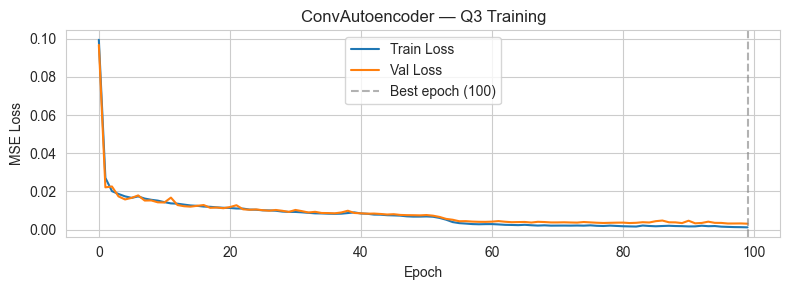


✓ Training complete.


In [10]:
print("="*60)
print("  TRAINING: ConvAutoencoder on Q3 (Summer)")
print("="*60)

# Build DataLoaders from Q3 splits
train_tensor = torch.from_numpy(data_splits["X_train"])
val_tensor = torch.from_numpy(data_splits["X_val"])

train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=CONFIG["batch_size"], shuffle=True
)
val_loader = DataLoader(
    TensorDataset(val_tensor), batch_size=CONFIG["batch_size"], shuffle=False
)

# Build and train model
model = ConvAutoencoder(latent_dim=CONFIG["latent_dim"]).to(device)

history = train_autoencoder(
    model, train_loader, val_loader,
    epochs=CONFIG["epochs"],
    lr=CONFIG["learning_rate"],
    patience=CONFIG["early_stop_patience"],
    device=device,
)

plot_loss_curves(history, title="ConvAutoencoder — Q3 Training")
torch.cuda.empty_cache() if device.type == "cuda" else None
print("\n✓ Training complete.")

## 10. Reconstruction Error Calculation and Drift Detection

Compute per-image MSE for every quarter. If reconstruction error on Q4 (or Q2) is significantly higher than Q3 test error, concept drift is detected.

**Statistical test:** Mann-Whitney U (non-parametric, two-sided) with $\alpha = 0.05$.

In [11]:
def calculate_reconstruction_errors(
    model: nn.Module,
    images: np.ndarray,
    device: torch.device,
    batch_size: int = CONFIG["batch_size"],
) -> np.ndarray:
    """
    Pass images through the autoencoder and compute per-image MSE.

    Returns:
        1-D np.ndarray of per-image MSE values.
    """
    model.eval()
    errors = []
    tensor = torch.from_numpy(images)
    loader = DataLoader(TensorDataset(tensor), batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            recon, _ = model(batch)
            mse = ((recon - batch) ** 2).mean(dim=(1, 2, 3)).cpu().numpy()
            errors.append(mse)
    return np.concatenate(errors)


# ── Compute errors for all quarters ──
ref_q = data_splits["reference_quarter"]
errors_ref = calculate_reconstruction_errors(model, data_splits["X_test_ref"], device)
print(f"{ref_q} (reference) test errors: mean={errors_ref.mean():.6f}, std={errors_ref.std():.6f}, n={len(errors_ref)}")

quarter_errors = {ref_q: errors_ref}
results_rows = []

for q in drift_quarters:
    key = f"X_test_{q}"
    err_q = calculate_reconstruction_errors(model, data_splits[key], device)
    quarter_errors[q] = err_q

    mean_ref = errors_ref.mean()
    std_ref = errors_ref.std()
    mean_q = err_q.mean()
    std_q = err_q.std()
    drift_pct = ((mean_q - mean_ref) / mean_ref) * 100
    stat, p_value = stats.mannwhitneyu(errors_ref, err_q, alternative="two-sided")

    results_rows.append({
        "Quarter": q,
        "N_Images": data_splits[f"n_test_{q}"],
        "Mean_MSE": mean_q,
        "Std_MSE": std_q,
        f"Ref_{ref_q}_Mean": mean_ref,
        f"Ref_{ref_q}_Std": std_ref,
        "Drift_%": drift_pct,
        "P_Value": p_value,
        "Drift_Detected": p_value < 0.05,
    })
    print(f"{q}: mean={mean_q:.6f}, std={std_q:.6f}, drift={drift_pct:+.2f}%, p={p_value:.2e}, drift={'YES' if p_value < 0.05 else 'NO'}")

results_df = pd.DataFrame(results_rows)
print("\n" + "="*80)
print("  SEASONAL DRIFT DETECTION RESULTS")
print("="*80)
display(results_df.style.format({
    "Mean_MSE": "{:.6f}",
    "Std_MSE": "{:.6f}",
    f"Ref_{ref_q}_Mean": "{:.6f}",
    f"Ref_{ref_q}_Std": "{:.6f}",
    "Drift_%": "{:+.2f}%",
    "P_Value": "{:.2e}",
}).highlight_between(subset=["Drift_%"], left=0, color="#ffe0e0"))

Q3 (reference) test errors: mean=0.003910, std=0.002731, n=40
Q4: mean=0.008821, std=0.005935, drift=+125.60%, p=1.35e-12, drift=YES

  SEASONAL DRIFT DETECTION RESULTS


,Quarter,N_Images,Mean_MSE,Std_MSE,Ref_Q3_Mean,Ref_Q3_Std,Drift_%,P_Value,Drift_Detected
0,Q4,203,0.008821,0.005935,0.003910,0.002731,+125.60%,1.35e-12,True


## 11. Visualization: Error Distributions and Comparisons

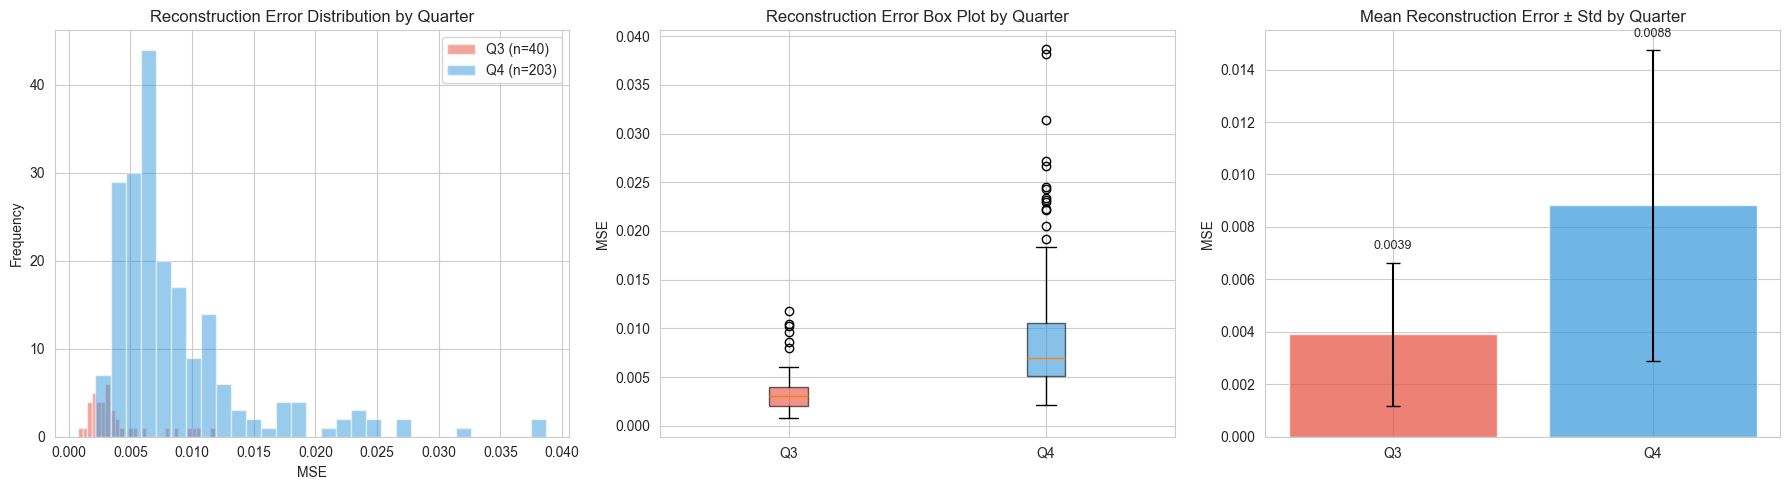

In [12]:
all_quarters = [ref_q] + drift_quarters
colors_q = {"Q3": "#e74c3c", "Q4": "#3498db"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Overlaid histograms ──
for q in all_quarters:
    axes[0].hist(quarter_errors[q], bins=30, alpha=0.5,
                 label=f"{q} (n={len(quarter_errors[q])})",
                 color=colors_q.get(q, "grey"))
axes[0].set_title("Reconstruction Error Distribution by Quarter")
axes[0].set_xlabel("MSE")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# ── 2. Box plots ──
box_data = [quarter_errors[q] for q in all_quarters]
bp = axes[1].boxplot(box_data, labels=all_quarters, patch_artist=True)
for patch, q in zip(bp["boxes"], all_quarters):
    patch.set_facecolor(colors_q.get(q, "grey"))
    patch.set_alpha(0.6)
axes[1].set_title("Reconstruction Error Box Plot by Quarter")
axes[1].set_ylabel("MSE")

# ── 3. Mean error bar chart with std ──
means = [quarter_errors[q].mean() for q in all_quarters]
stds = [quarter_errors[q].std() for q in all_quarters]
bar_colors = [colors_q.get(q, "grey") for q in all_quarters]
axes[2].bar(all_quarters, means, yerr=stds, color=bar_colors, alpha=0.7, capsize=5)
axes[2].set_title("Mean Reconstruction Error ± Std by Quarter")
axes[2].set_ylabel("MSE")
for i, (m, s) in enumerate(zip(means, stds)):
    axes[2].text(i, m + s + 0.0005, f"{m:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

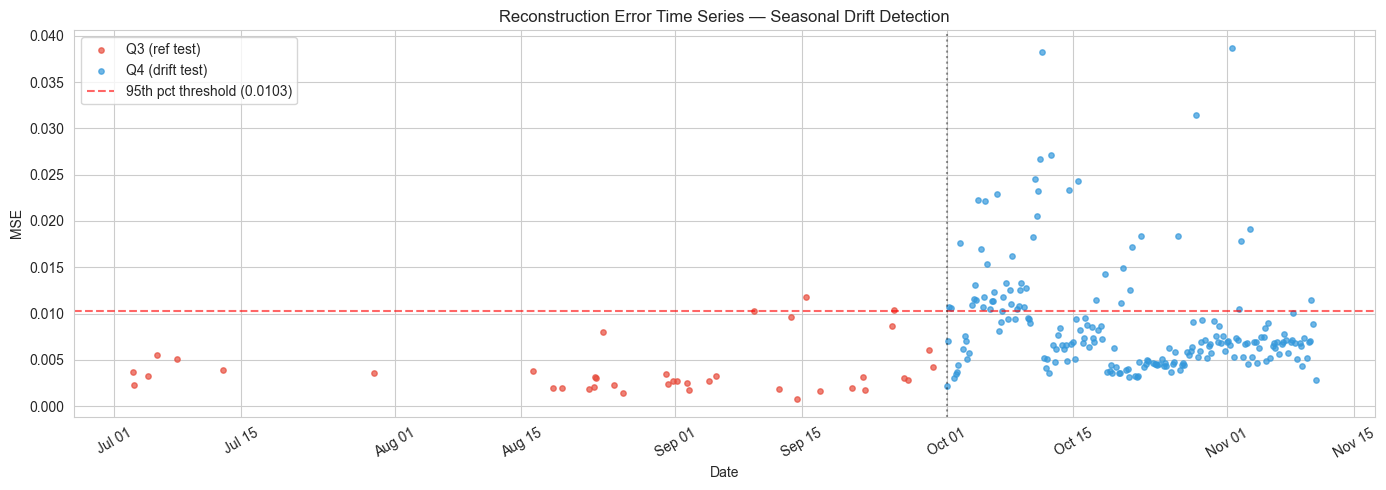

In [13]:
# ── Reconstruction error time series ──
fig, ax = plt.subplots(figsize=(14, 5))

# Reference quarter test set
ax.scatter(data_splits["dates_test_ref"], errors_ref,
           c=colors_q.get(ref_q, "grey"), s=15, alpha=0.7, label=f"{ref_q} (ref test)")

# Drift quarters
for q in drift_quarters:
    dates_q = data_splits[f"dates_test_{q}"]
    ax.scatter(dates_q, quarter_errors[q],
               c=colors_q.get(q, "grey"), s=15, alpha=0.7, label=f"{q} (drift test)")

# Threshold line (95th percentile of reference)
threshold = np.percentile(errors_ref, 95)
ax.axhline(threshold, color="red", ls="--", alpha=0.6, label=f"95th pct threshold ({threshold:.4f})")

# Quarter boundary
ax.axvline(datetime(2024, 10, 1), color="black", ls=":", alpha=0.4)

ax.set_title("Reconstruction Error Time Series — Seasonal Drift Detection")
ax.set_xlabel("Date")
ax.set_ylabel("MSE")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(loc="upper left")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

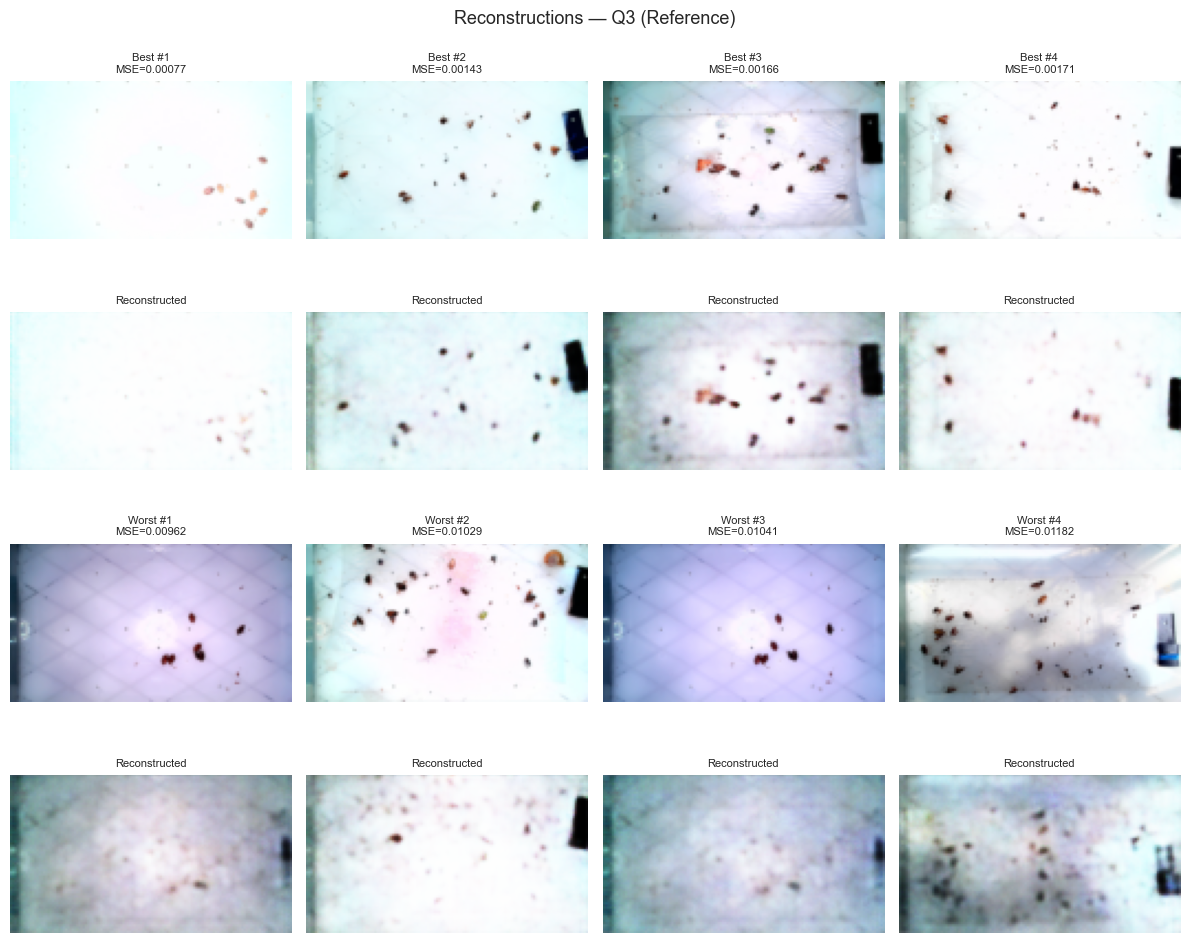

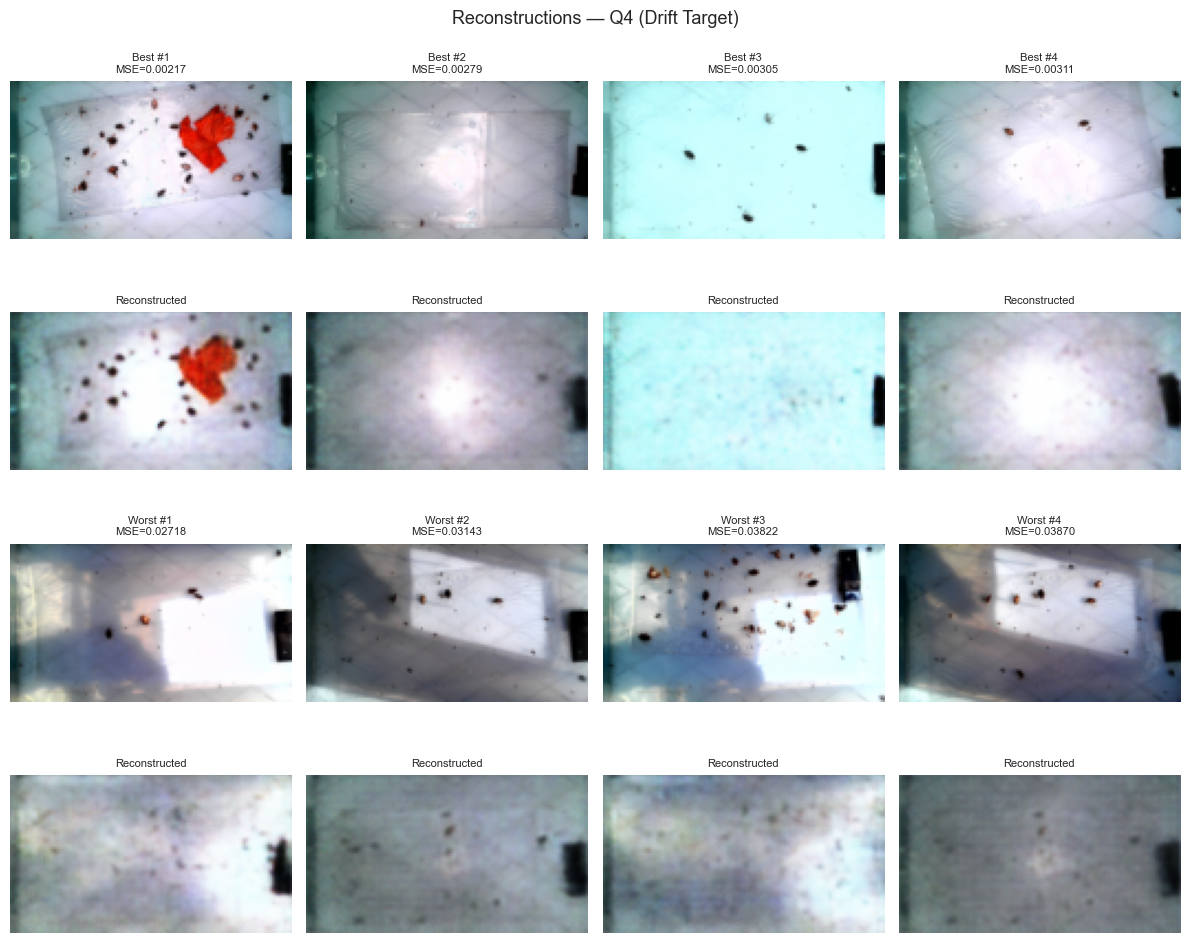

In [14]:
# ── Show sample reconstructions: best and worst per quarter ──
def show_reconstructions(model, images, quarter_label, n=4):
    """Display original vs reconstructed images (best and worst MSE)."""
    model.eval()
    tensor = torch.from_numpy(images).to(device)
    with torch.no_grad():
        recon, _ = model(tensor)
    mse_per = ((recon - tensor) ** 2).mean(dim=(1, 2, 3)).cpu().numpy()

    best_idx = np.argsort(mse_per)[:n]
    worst_idx = np.argsort(mse_per)[-n:]

    fig, axes = plt.subplots(4, n, figsize=(3 * n, 10))
    fig.suptitle(f"Reconstructions — {quarter_label}", fontsize=13)

    for col, idx in enumerate(best_idx):
        orig = images[idx].transpose(1, 2, 0)
        rec = recon[idx].cpu().numpy().transpose(1, 2, 0)
        axes[0, col].imshow(orig)
        axes[0, col].set_title(f"Best #{col+1}\nMSE={mse_per[idx]:.5f}", fontsize=8)
        axes[0, col].axis("off")
        axes[1, col].imshow(rec)
        axes[1, col].set_title("Reconstructed", fontsize=8)
        axes[1, col].axis("off")

    for col, idx in enumerate(worst_idx):
        orig = images[idx].transpose(1, 2, 0)
        rec = recon[idx].cpu().numpy().transpose(1, 2, 0)
        axes[2, col].imshow(orig)
        axes[2, col].set_title(f"Worst #{col+1}\nMSE={mse_per[idx]:.5f}", fontsize=8)
        axes[2, col].axis("off")
        axes[3, col].imshow(rec)
        axes[3, col].set_title("Reconstructed", fontsize=8)
        axes[3, col].axis("off")

    axes[0, 0].set_ylabel("Best\nOriginal", fontsize=9)
    axes[1, 0].set_ylabel("Best\nReconstructed", fontsize=9)
    axes[2, 0].set_ylabel("Worst\nOriginal", fontsize=9)
    axes[3, 0].set_ylabel("Worst\nReconstructed", fontsize=9)
    plt.tight_layout()
    plt.show()


# Show for reference and drift quarters
show_reconstructions(model, data_splits["X_test_ref"], f"{ref_q} (Reference)")
for q in drift_quarters:
    show_reconstructions(model, data_splits[f"X_test_{q}"], f"{q} (Drift Target)")

## 12. Drift Analysis by Trap Replacement

Since sticky traps are replaced periodically, each trap replacement resets the visual baseline. Analyze whether trap changes amplify or confound seasonal drift.

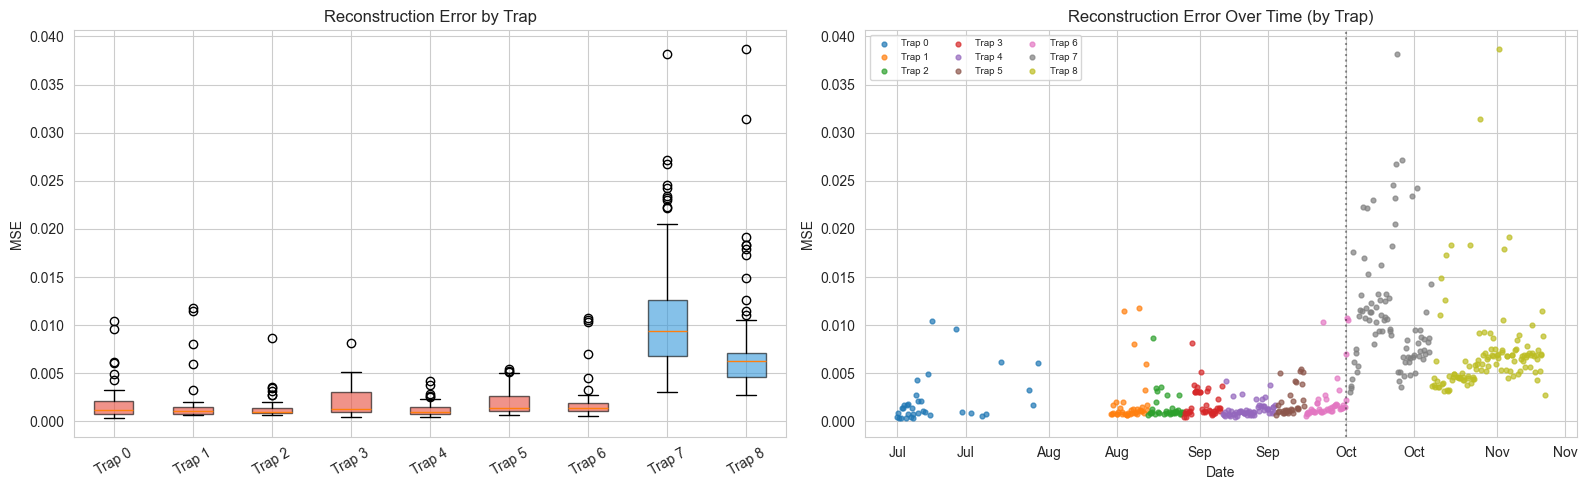


Reconstruction error by trap and quarter:


n_images  mean_mse   std_mse
trap quarter                              
0    Q3             34  0.002183  0.002520
1    Q3             36  0.002049  0.002776
2    Q3             32  0.001551  0.001538
3    Q3             40  0.001968  0.001539
4    Q3             54  0.001266  0.000765
5    Q3             30  0.002127  0.001555
6    Q3             40  0.001701  0.001577
     Q4              4  0.007617  0.004011
7    Q4             84  0.011172  0.006531
8    Q4            115  0.007145  0.004929

In [15]:
# ── Compute reconstruction errors for ALL images (not just test splits) ──
all_errors = calculate_reconstruction_errors(
    model,
    load_images_from_paths(catalogue["filepath"].tolist()),
    device
)
catalogue["recon_error"] = all_errors

# ── Error by trap ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box plot by trap
trap_ids = sorted(catalogue["trap"].unique())
trap_data = [catalogue[catalogue["trap"] == t]["recon_error"].values for t in trap_ids]
bp = axes[0].boxplot(trap_data, labels=[f"Trap {t}" for t in trap_ids], patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    q = catalogue[catalogue["trap"] == trap_ids[i]]["quarter"].mode().iloc[0]
    patch.set_facecolor(colors_q.get(q, "grey"))
    patch.set_alpha(0.6)
axes[0].set_title("Reconstruction Error by Trap")
axes[0].set_ylabel("MSE")
axes[0].tick_params(axis="x", rotation=30)

# Scatter: error over time colored by trap
cmap = plt.cm.tab10
for t in trap_ids:
    subset = catalogue[catalogue["trap"] == t]
    axes[1].scatter(subset["datetime"], subset["recon_error"],
                    c=[cmap(t / 9)], s=12, alpha=0.7, label=f"Trap {t}")

axes[1].axvline(datetime(2024, 10, 1), color="black", ls=":", alpha=0.4)
axes[1].set_title("Reconstruction Error Over Time (by Trap)")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("MSE")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[1].legend(fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

# Summary stats by trap
trap_summary = catalogue.groupby(["trap", "quarter"]).agg(
    n_images=("recon_error", "count"),
    mean_mse=("recon_error", "mean"),
    std_mse=("recon_error", "std"),
).round(6)
print("\nReconstruction error by trap and quarter:")
display(trap_summary)

## 13. MTTD Analysis — Mean Time to Detect Drift

Using the 95th percentile of Q3 reconstruction error as the threshold, measure how many consecutive images in Q4 exceed this threshold before drift is confirmed.

**MTTD** = number of images (and wall-clock time) from the start of Q4 until $k=3$ consecutive detections.

In [16]:
def compute_mttd(
    errors: np.ndarray,
    dates: list,
    threshold: float,
    consecutive_k: int = 3,
):
    """
    Compute Mean Time To Detect (MTTD).

    Returns:
        dict with detection_index, detection_date, mttd_frames, mttd_hours,
        detection_rate
    """
    detections = errors > threshold
    detection_rate = detections.mean() * 100

    # Find first run of consecutive_k detections
    run = 0
    first_detection_idx = None
    for i, det in enumerate(detections):
        if det:
            run += 1
            if run >= consecutive_k:
                first_detection_idx = i - consecutive_k + 1
                break
        else:
            run = 0

    if first_detection_idx is not None:
        dt_start = dates[0]
        dt_detect = dates[first_detection_idx]
        mttd_hours = (dt_detect - dt_start).total_seconds() / 3600
    else:
        first_detection_idx = -1
        mttd_hours = float("inf")

    return {
        "detection_index": first_detection_idx,
        "mttd_frames": first_detection_idx if first_detection_idx >= 0 else len(errors),
        "mttd_hours": mttd_hours,
        "detection_rate_%": detection_rate,
    }


threshold_95 = np.percentile(errors_ref, 95)
print(f"95th percentile threshold (Q3 reference): {threshold_95:.6f}")
print()

mttd_rows = []
for q in drift_quarters:
    err_q = quarter_errors[q]
    dates_q = data_splits[f"dates_test_{q}"]
    mttd = compute_mttd(err_q, dates_q, threshold_95)
    mttd["quarter"] = q
    mttd_rows.append(mttd)
    print(f"{q}: MTTD={mttd['mttd_frames']} frames ({mttd['mttd_hours']:.1f} hrs), detection_rate={mttd['detection_rate_%']:.1f}%")

mttd_df = pd.DataFrame(mttd_rows)
display(mttd_df)

95th percentile threshold (Q3 reference): 0.010295

Q4: MTTD=14 frames (66.0 hrs), detection_rate=25.6%


,detection_index,mttd_frames,mttd_hours,detection_rate_%,quarter
0,14,14,66.000278,25.615764,Q4


## 14. Save Results

In [17]:
# Save drift detection results
results_path = os.path.join(CONFIG["output_dir"], "seasonal_drift_results.csv")
results_df.to_csv(results_path, index=False)
print(f"Drift results saved to {results_path}")

# Save MTTD results
mttd_path = os.path.join(CONFIG["output_dir"], "seasonal_mttd_analysis.csv")
mttd_df.to_csv(mttd_path, index=False)
print(f"MTTD results saved to {mttd_path}")

# Save per-image errors with metadata
errors_path = os.path.join(CONFIG["output_dir"], "seasonal_per_image_errors.csv")
catalogue[["filename", "datetime", "quarter", "trap", "num_hh", "recon_error"]].to_csv(errors_path, index=False)
print(f"Per-image errors saved to {errors_path}")

Drift results saved to ..\results\seasonal_drift_results.csv
MTTD results saved to ..\results\seasonal_mttd_analysis.csv
Per-image errors saved to ..\results\seasonal_per_image_errors.csv


## Discussion and Conclusion

This project set out to answer a surprisingly practical question: can you tell, automatically and without any labels, when an IoT camera has started seeing something meaningfully different from what it was trained on? Across three very different real-world datasets, the answer turned out to be a consistent yes.

We started with **22 Bristol streetlight cameras** (Dataset 1), training a VAE purely on winter images and then checking how well it could reconstruct summer ones. Reconstruction error spiked — and a permutation test confirmed the shift was real, not random noise. Interestingly, day and night images drifted by almost exactly the same amount (~19–20%), which ruled out the cameras' automatic lighting mode as the culprit; the drift is genuinely seasonal. Swapping in a better VAE architecture (BatchNorm, larger latent space, tuned learning rate) alone cut the drift score by a third, which showed that model choice matters even in an unsupervised setting.

Moving to **9 agricultural Raspberry Pi sensors on a pomegranate farm** (Dataset 2) made the scale of drift much more dramatic. Models trained on 2021 images were tested on 2022 data, and every single sensor showed statistically significant drift — with reconstruction errors jumping by an average of +580% to +817% depending on the architecture. Year-on-year outdoor environmental change is simply a lot bigger than one season to the next in an urban context. The cross-domain penalty factor came out at nearly 2×, meaning the detection threshold needs roughly doubling when you deploy a model outside its training year.

For the **BMSB sticky-trap camera** (Dataset 3), we compared four autoencoder architectures and six streaming drift detectors on summer vs. autumn images. Reconstruction error rose +125.6% (p < 10⁻¹²), the best model (ResAttnAE) hit an F1 of 0.956, and mean time to detection was about 66 hours from the start of the new season — useful information for anyone scheduling pest-monitoring inspections. One clear lesson here: VAEs can collapse on small datasets (ours stopped at epoch 11), so they need careful handling.

Across all three datasets, a reassuring pattern held: the reconstruction signal was *not* simply tracking brightness or image contrast. Pearson correlations between environmental variance and drift sensitivity were close to zero in Datasets 2 and 3, which suggests the models are picking up on something structural in the data distribution rather than just surface-level lighting changes.

**Future work** would naturally extend this to longer timelines (multi-year trend analysis), move from batch to streaming detection so alerts fire in real time, and explore whether a model trained in one city or farm can be cheaply adapted to a new deployment site via few-shot fine-tuning. Collecting ground-truth fault records from the network operators would also let us convert these statistical findings into proper precision/recall numbers.